Why we chose to change our dataset for the project?

Initially, we planned to use the NHANES dataset that included information from the "National Health and Nutrition Examination Survey. This dataset was extremely complex with various sub-datasets including information from demographics, lab tests, health exams, dietary data, questionnaire data, etc. It contained various types of data as well. We realized that if we were to use this dataset, we would need to merge multiple sub-datasets together and parse through thousands of columns of different variable types. Also, the data initally comes in XPT files that would need to be merged then converted to CSV. Therefore, we switched to using another dataset found on Kaggle. The dataset is named "Students Performance in Exams", and has a sufficient amount of information and is well-organized. It is a csv file that includes a few variables such as gender, race, parental level of education, school lunch plan, and test preparation level along with numerical data such as exam scores. We felt like this dataset is more straightforward and will allow us to make real hypotheses. This data is also impactful because our project will allow us to understand how varying factors that we may not have initally assumed to affect students' exam performance actually do. 

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Load and view the dataset
df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Make column names into one string
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Rename some columns with a better description
df = df.rename(columns = {
    "race/ethnicity": "race",
    "lunch": "lunch_plan",
    "test_preparation_course": "test_prep_status"
})
df.head()

,gender,race,parental_level_of_education,lunch_plan,test_prep_status,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
# Checking for any missing values. None, so we are good!
df.isnull().sum()

gender                         0
race                           0
parental_level_of_education    0
lunch_plan                     0
test_prep_status               0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [5]:
# Check column data types
df.dtypes

gender                         object
race                           object
parental_level_of_education    object
lunch_plan                     object
test_prep_status               object
math_score                      int64
reading_score                   int64
writing_score                   int64
dtype: object

In [6]:
# The scores are good already since they are integers. We need to make the first five columns into categorical data types, though.
categorical_columns = [
    "gender", "race", "parental_level_of_education", 
    "lunch_plan", "test_prep_status"
]

for col in categorical_columns:
    df[col] = df[col].astype("category")

df.dtypes

gender                         category
race                           category
parental_level_of_education    category
lunch_plan                     category
test_prep_status               category
math_score                        int64
reading_score                     int64
writing_score                     int64
dtype: object

Question #1: Does taking a prep course improve math grades?

Hypothesis test used to interpret conclusion #1: ANOVA on the average math scores between racial groups

Null Hypothesis (Ho): The mean math score is the same across all race/ethnicity groups.
Alternative Hypothesis (Ha): At least one race/ethnicity group has a different mean math score.

In [7]:
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt


groups = [group["math_score"].values for name, group in df.groupby("race")]
f_stat, p_value = f_oneway(*groups)

print("ANOVA (scipy)")
print("F-statistic:", f_stat)
print("p-value:", p_value)
print("A one-way ANOVA was conducted to compare math scores across racial groups. A Tukey HSD post-hoc test was performed to identify which exact group differed.")


ANOVA (scipy)
F-statistic: 14.593885166332635
p-value: 1.373219403037064e-11
A one-way ANOVA was conducted to compare math scores across racial groups. A Tukey HSD post-hoc test was performed to identify which exact group differed.


/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_38477/3426533319.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group["math_score"].values for name, group in df.groupby("race")]


In [8]:
tukey = pairwise_tukeyhsd(
    endog=df["math_score"],
    groups=df["race"],
    alpha=0.05
)

print("\nTukey HSD Results:")
print(tukey)
print("The initial ANOVA showed a significant influence of race/ethnicity on math scores (F = 14.59 , p-value = 1.37 x 10^-11). Post-hoc analysis shows that there's a statistically significant \ndifference between groups A&D, A&E, B&D, B&E, C&E, and D&E. The other pairings fail to reject the null hypothesis that there is no difference in means amongst math scores.")


Tukey HSD Results:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
group A group B   1.8234 0.8724   -3.36  7.0068  False
group A group C   2.8347 0.4968 -2.0028  7.6723  False
group A group D   5.7334 0.0138  0.7824 10.6844   True
group A group E  12.1922    0.0  6.7215 17.6629   True
group B group C   1.0113 0.9452 -2.6867  4.7094  False
group B group D     3.91  0.044  0.0647  7.7552   True
group B group E  10.3688    0.0  5.8741 14.8635   True
group C group D   2.8986  0.129 -0.4659  6.2632  False
group C group E   9.3575    0.0  5.2665 13.4485   True
group D group E   6.4588 0.0003  2.2343 10.6834   True
------------------------------------------------------
The initial ANOVA showed a significant influence of race/ethnicity on math scores (F = 14.59 , p-value = 1.37 x 10^-11). Post-hoc analysis shows that there's a statistically significant 
difference between grou

<Figure size 640x480 with 0 Axes>

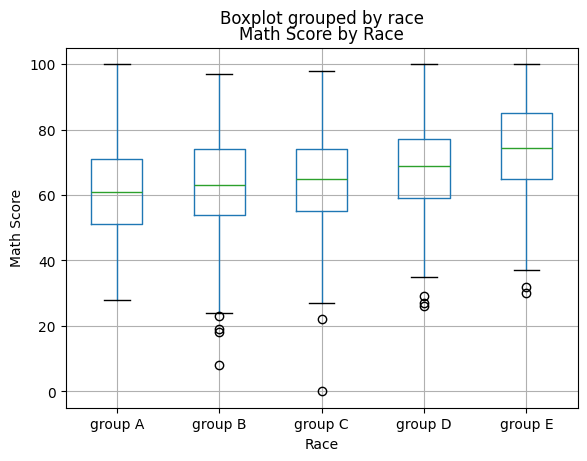

This box plot suggests that math performance varies significantly across racial/ethnic groups.


In [9]:
plt.figure()
df.boxplot(column="math_score", by="race")
plt.title("Math Score by Race")
plt.xlabel("Race")
plt.ylabel("Math Score")
plt.show()
print("This box plot suggests that math performance varies significantly across racial/ethnic groups.")

Question #2: Does taking a prep course improve math grades?

Hypothesis test used to interpret conclusion #2: T-test

Null Hypothesis (Ho): There is no difference in mean math scores between students that completed the math course and the ones who did.
Alternative Hypothesis (Ha): Students who completed the test prep have higher mean math scored.

In [10]:
from scipy.stats import ttest_ind

# First seperate the non test prep and test prep students 
completed = df[df['test_prep_status'] == 'completed']['math_score']
none= df[df['test_prep_status'] == 'none']['math_score']

# T-test
stat, p=ttest_ind(completed, none)

print('p-value:', p)

if p< 0.05: 
    print("Reject null hypothesis: Test prep does affect math scores")
else: 
    print('fail to reject null hypothesis')

p-value: 1.5359134607147415e-08
Reject null hypothesis: Test prep does affect math scores


/var/folders/t9/l9t3k75x6ql2n7syxl42t2kh0000gn/T/ipykernel_38477/3494032876.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')


Text(0, 0.5, 'Math score')

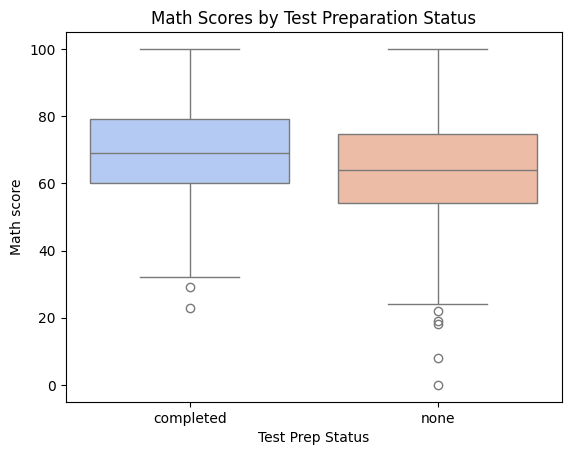

In [11]:
sns.boxplot(data=df, x='test_prep_status', y='math_score', palette='coolwarm')
plt.title("Math Scores by Test Preparation Status")
plt.xlabel("Test Prep Status")
plt.ylabel('Math score')

Question #3: Does parental level of education have an effect on student lunch plan.

Hypothesis test used to interpret conclusion #3: Chi-Squared Test

Null Hypothesis (Ho): Parental level of education has no effect on student lunch plan
Alternative Hypothesis (Ha): Parental level of education has an effect on student lunch plan

In [12]:
from scipy.stats import chi2_contingency

# Hypothesis testing: Chi-squared test
contingency_table = pd.crosstab(df["parental_level_of_education"], df["lunch_plan"])
stat, p, dof, expected = chi2_contingency(contingency_table)
print(f"P-value: {p}")
print("Using an alpha value of 0.05, we find that the p-value is greater than 0.05, meaning that the data is not significant and we accept the null hypothesis. \nParental level of education has no effect on student lunch plan.")

P-value: 0.9531014927218224
Using an alpha value of 0.05, we find that the p-value is greater than 0.05, meaning that the data is not significant and we accept the null hypothesis. 
Parental level of education has no effect on student lunch plan.


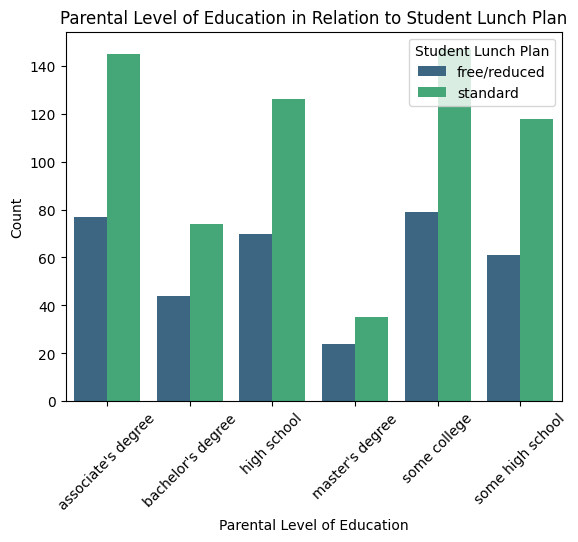

In [13]:
# Plotting relationship between parental level of education and lunch plan
sns.countplot(data = df, x = "parental_level_of_education", hue = "lunch_plan", palette = "viridis")
plt.xticks(rotation = 45)
plt.xlabel("Parental Level of Education")
plt.ylabel("Count")
plt.title("Parental Level of Education in Relation to Student Lunch Plan")
plt.legend(title = "Student Lunch Plan")